# Graph Analizi

Bu notebook, WikiCS custom graph üzerinde çeşitli graph analiz metriklerini hesaplar:

1. **Degree Distribution Histogramı**
2. **Degree Assortativity**
3. **Topic ile Link Structure Assortativity** (Embedding vektörleri ile)
   - Cosine Similarity
   - Pearson Correlation
   - Euclidean Distance
4. **Local Transitivity (Clustering Coefficient) Dağılım Histogramı**

## 1. Veri Yükleme ve Graf Oluşturma

In [1]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import pearsonr
from collections import Counter

In [2]:
# Veriyi yükle
with open("../../data/data-embeddings.json", "r") as f:
    data = json.load(f)

print(f"Toplam node sayısı: {len(data['nodes'])}")

Toplam node sayısı: 11701


In [3]:
# Embeddings'i yükle
df_emb = pd.read_parquet("../../cap-embeddings/BAAI_bge-m3/master_embeddings.parquet")
print(f"Toplam embedding sayısı: {len(df_emb)}")
df_emb.head()

Toplam embedding sayısı: 11701


,id,embedding
0,36274176,"[-0.0024356842041015625, 0.040802001953125, -0..."
1,3145747,"[-0.0024356842041015625, 0.040802001953125, -0..."
2,46366812,"[-0.0024356842041015625, 0.040802001953125, -0..."
3,37945465,"[-0.0024356842041015625, 0.040802001953125, -0..."
4,37617853,"[-0.0024356842041015625, 0.040802001953125, -0..."


In [4]:
# Node ID'lerini set olarak tut (hızlı lookup için)
node_ids = set()
for node in data["nodes"]:
    node_ids.add(node["id"])

print(f"Toplam unique node ID: {len(node_ids)}")

Toplam unique node ID: 11701


In [5]:
# NetworkX grafını oluştur
G = nx.DiGraph()

# Node'ları ekle (label bilgisi ile)
for node in data["nodes"]:
    G.add_node(node["id"], title=node["title"], label=node.get("label", "Unknown"))

# Edge'leri ekle (sadece grafta olan node'lara bağlantılar)
for node in data["nodes"]:
    src = node["id"]
    for tgt in node.get("outlinks", []):
        if tgt in node_ids:
            G.add_edge(src, tgt)

print(f"Node sayısı: {G.number_of_nodes()}")
print(f"Edge sayısı: {G.number_of_edges()}")

Node sayısı: 11701
Edge sayısı: 291039


In [6]:
# Embedding lookup dict oluştur (id -> embedding numpy array)
emb_dict = {}
for _, row in df_emb.iterrows():
    emb_dict[str(row["id"])] = np.array(row["embedding"])

print(f"Embedding dict boyutu: {len(emb_dict)}")
print(f"Embedding boyutu: {len(list(emb_dict.values())[0])}")

Embedding dict boyutu: 11701
Embedding boyutu: 1024


## 2. Degree Distribution Histogramı

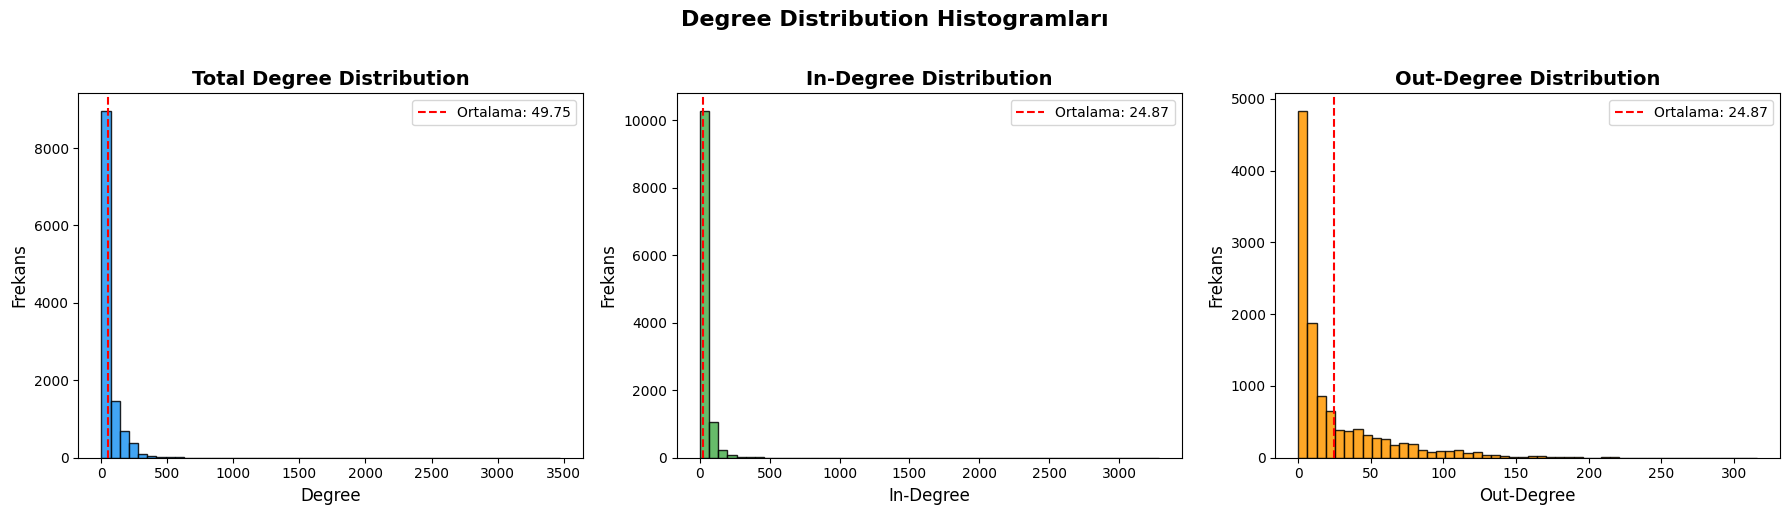


Degree İstatistikleri:
  Total Degree  -> Min: 0, Max: 3474, Ortalama: 49.75, Medyan: 14
  In-Degree     -> Min: 0, Max: 3283, Ortalama: 24.87, Medyan: 4
  Out-Degree    -> Min: 0, Max: 316, Ortalama: 24.87, Medyan: 9


In [7]:
# Total degree (in + out) dağılımını hesapla
degrees = [G.degree(n) for n in G.nodes()]
in_degrees = [G.in_degree(n) for n in G.nodes()]
out_degrees = [G.out_degree(n) for n in G.nodes()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Degree
axes[0].hist(degrees, bins=50, color='#2196F3', edgecolor='black', alpha=0.85)
axes[0].set_title('Total Degree Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Degree', fontsize=12)
axes[0].set_ylabel('Frekans', fontsize=12)
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Ortalama: {np.mean(degrees):.2f}')
axes[0].legend(fontsize=10)

# In-Degree
axes[1].hist(in_degrees, bins=50, color='#4CAF50', edgecolor='black', alpha=0.85)
axes[1].set_title('In-Degree Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('In-Degree', fontsize=12)
axes[1].set_ylabel('Frekans', fontsize=12)
axes[1].axvline(np.mean(in_degrees), color='red', linestyle='--', label=f'Ortalama: {np.mean(in_degrees):.2f}')
axes[1].legend(fontsize=10)

# Out-Degree
axes[2].hist(out_degrees, bins=50, color='#FF9800', edgecolor='black', alpha=0.85)
axes[2].set_title('Out-Degree Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Out-Degree', fontsize=12)
axes[2].set_ylabel('Frekans', fontsize=12)
axes[2].axvline(np.mean(out_degrees), color='red', linestyle='--', label=f'Ortalama: {np.mean(out_degrees):.2f}')
axes[2].legend(fontsize=10)

plt.suptitle('Degree Distribution Histogramları', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nDegree İstatistikleri:")
print(f"  Total Degree  -> Min: {min(degrees)}, Max: {max(degrees)}, Ortalama: {np.mean(degrees):.2f}, Medyan: {np.median(degrees):.0f}")
print(f"  In-Degree     -> Min: {min(in_degrees)}, Max: {max(in_degrees)}, Ortalama: {np.mean(in_degrees):.2f}, Medyan: {np.median(in_degrees):.0f}")
print(f"  Out-Degree    -> Min: {min(out_degrees)}, Max: {max(out_degrees)}, Ortalama: {np.mean(out_degrees):.2f}, Medyan: {np.median(out_degrees):.0f}")

### Log-Log Scale Degree Distribution

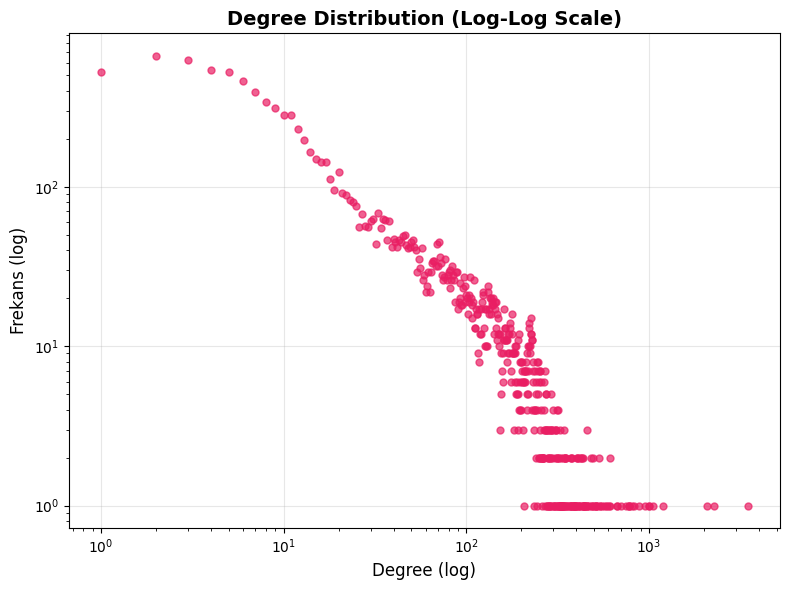

In [8]:
# Log-log scale'da degree distribution (power-law kontrolü için)
degree_count = Counter(degrees)
deg, cnt = zip(*sorted(degree_count.items()))

plt.figure(figsize=(8, 6))
plt.loglog(deg, cnt, 'o', markersize=5, color='#E91E63', alpha=0.7)
plt.title('Degree Distribution (Log-Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Degree (log)', fontsize=12)
plt.ylabel('Frekans (log)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Degree Assortativity

In [9]:
# Degree Assortativity Coefficient
# Pozitif değer: yüksek dereceli node'lar yüksek dereceli node'lara bağlanma eğiliminde (assortative)
# Negatif değer: yüksek dereceli node'lar düşük dereceli node'lara bağlanma eğiliminde (disassortative)

r = nx.degree_assortativity_coefficient(G)
print(f"Degree Assortativity Coefficient: {r:.6f}")

if r > 0:
    print("→ Graf ASSORTATIVE: Yüksek dereceli node'lar yüksek dereceli node'lara bağlanma eğiliminde.")
elif r < 0:
    print("→ Graf DISASSORTATIVE: Yüksek dereceli node'lar düşük dereceli node'lara bağlanma eğiliminde.")
else:
    print("→ Graf NÖTR: Bağlantılarda degree tercihi yok.")

Degree Assortativity Coefficient: -0.091838
→ Graf DISASSORTATIVE: Yüksek dereceli node'lar düşük dereceli node'lara bağlanma eğiliminde.


## 4. Topic ile Link Structure Assortativity

Bağlı node çiftlerinin embedding vektörleri arasındaki benzerliği/uzaklığı ölçüyoruz.
Bu, topic benzerliğinin (embedding ile temsil edilen) link yapısı ile ne kadar ilişkili olduğunu gösterir.

Her edge için embedding benzerliği/uzaklığı hesaplanır, ardından ortalama ve dağılım raporlanır.
Ayrıca rastgele (bağlı olmayan) node çiftleriyle karşılaştırma yapılır.

In [10]:
# Her edge için embedding benzerlik/uzaklık metriklerini hesapla
cosine_sims = []
pearson_corrs = []
euclidean_dists = []

skipped = 0
for u, v in G.edges():
    u_str, v_str = str(u), str(v)
    if u_str in emb_dict and v_str in emb_dict:
        emb_u = emb_dict[u_str]
        emb_v = emb_dict[v_str]
        
        # Cosine Similarity (1 - cosine distance)
        cos_sim = 1 - cosine(emb_u, emb_v)
        cosine_sims.append(cos_sim)
        
        # Pearson Correlation
        corr, _ = pearsonr(emb_u, emb_v)
        pearson_corrs.append(corr)
        
        # Euclidean Distance
        euc_dist = euclidean(emb_u, emb_v)
        euclidean_dists.append(euc_dist)
    else:
        skipped += 1

print(f"Hesaplanan edge sayısı: {len(cosine_sims)}")
print(f"Embedding bulunamayan edge sayısı: {skipped}")

Hesaplanan edge sayısı: 291039
Embedding bulunamayan edge sayısı: 0


In [11]:
# Rastgele (bağlı olmayan) node çiftleri için aynı metrikleri hesapla (baseline karşılaştırma)
np.random.seed(42)
node_list = [n for n in G.nodes() if str(n) in emb_dict]
n_random = min(len(cosine_sims), 50000)  # En fazla 50000 rastgele çift

random_cosine = []
random_pearson = []
random_euclid = []

for _ in range(n_random):
    i, j = np.random.choice(len(node_list), 2, replace=False)
    emb_u = emb_dict[str(node_list[i])]
    emb_v = emb_dict[str(node_list[j])]
    
    random_cosine.append(1 - cosine(emb_u, emb_v))
    corr, _ = pearsonr(emb_u, emb_v)
    random_pearson.append(corr)
    random_euclid.append(euclidean(emb_u, emb_v))

print(f"Rastgele çift sayısı: {n_random}")

Rastgele çift sayısı: 50000


### 4.1 Cosine Similarity ile Topic-Link Assortativity

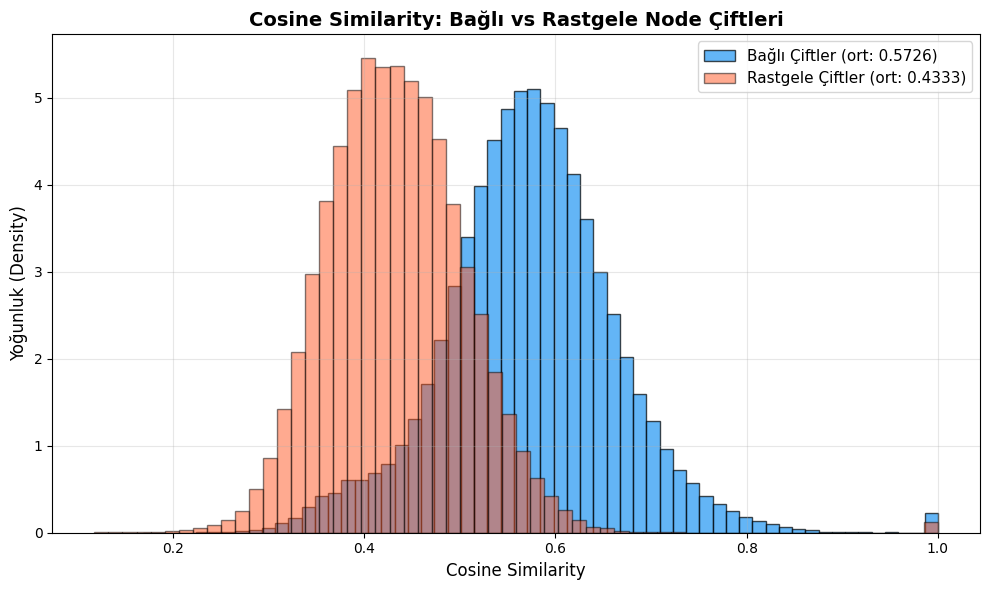

Bağlı çiftler - Cosine Sim Ortalama: 0.5726, Std: 0.0901
Rastgele çiftler - Cosine Sim Ortalama: 0.4333, Std: 0.0737


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(cosine_sims, bins=60, alpha=0.7, color='#2196F3', edgecolor='black', label=f'Bağlı Çiftler (ort: {np.mean(cosine_sims):.4f})', density=True)
ax.hist(random_cosine, bins=60, alpha=0.5, color='#FF5722', edgecolor='black', label=f'Rastgele Çiftler (ort: {np.mean(random_cosine):.4f})', density=True)

ax.set_title('Cosine Similarity: Bağlı vs Rastgele Node Çiftleri', fontsize=14, fontweight='bold')
ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Yoğunluk (Density)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bağlı çiftler - Cosine Sim Ortalama: {np.mean(cosine_sims):.4f}, Std: {np.std(cosine_sims):.4f}")
print(f"Rastgele çiftler - Cosine Sim Ortalama: {np.mean(random_cosine):.4f}, Std: {np.std(random_cosine):.4f}")

### 4.2 Pearson Correlation ile Topic-Link Assortativity

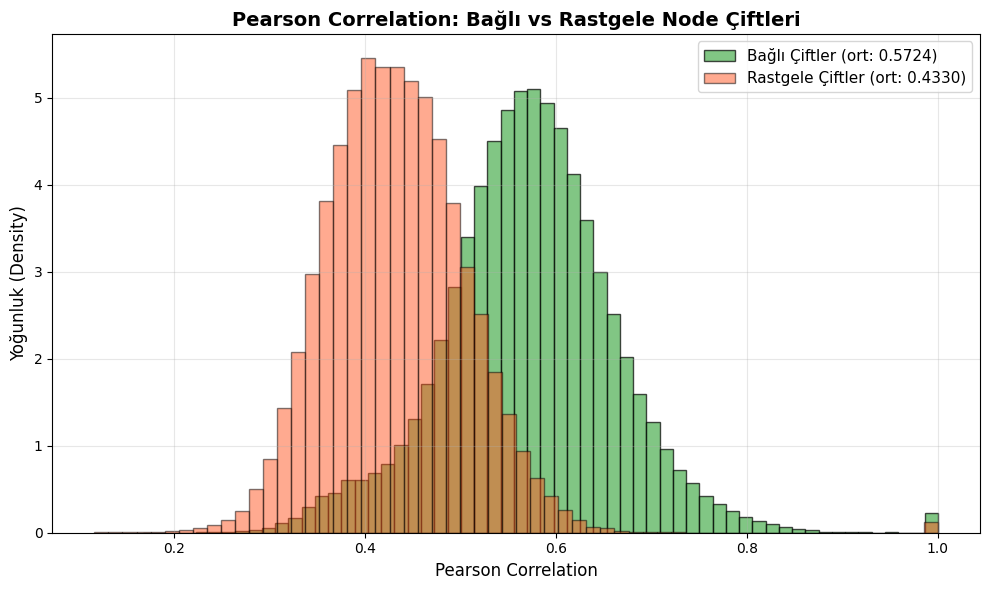

Bağlı çiftler - Pearson Corr Ortalama: 0.5724, Std: 0.0902
Rastgele çiftler - Pearson Corr Ortalama: 0.4330, Std: 0.0737


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(pearson_corrs, bins=60, alpha=0.7, color='#4CAF50', edgecolor='black', label=f'Bağlı Çiftler (ort: {np.mean(pearson_corrs):.4f})', density=True)
ax.hist(random_pearson, bins=60, alpha=0.5, color='#FF5722', edgecolor='black', label=f'Rastgele Çiftler (ort: {np.mean(random_pearson):.4f})', density=True)

ax.set_title('Pearson Correlation: Bağlı vs Rastgele Node Çiftleri', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation', fontsize=12)
ax.set_ylabel('Yoğunluk (Density)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bağlı çiftler - Pearson Corr Ortalama: {np.mean(pearson_corrs):.4f}, Std: {np.std(pearson_corrs):.4f}")
print(f"Rastgele çiftler - Pearson Corr Ortalama: {np.mean(random_pearson):.4f}, Std: {np.std(random_pearson):.4f}")

### 4.3 Euclidean Distance ile Topic-Link Assortativity

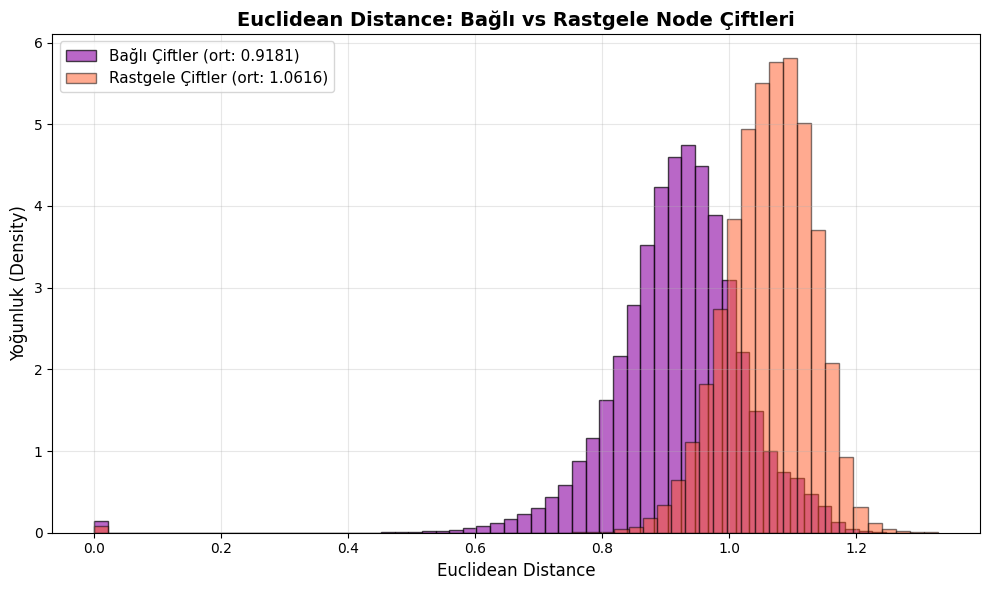

Bağlı çiftler - Euclidean Dist Ortalama: 0.9181, Std: 0.1089
Rastgele çiftler - Euclidean Dist Ortalama: 1.0616, Std: 0.0802


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(euclidean_dists, bins=60, alpha=0.7, color='#9C27B0', edgecolor='black', label=f'Bağlı Çiftler (ort: {np.mean(euclidean_dists):.4f})', density=True)
ax.hist(random_euclid, bins=60, alpha=0.5, color='#FF5722', edgecolor='black', label=f'Rastgele Çiftler (ort: {np.mean(random_euclid):.4f})', density=True)

ax.set_title('Euclidean Distance: Bağlı vs Rastgele Node Çiftleri', fontsize=14, fontweight='bold')
ax.set_xlabel('Euclidean Distance', fontsize=12)
ax.set_ylabel('Yoğunluk (Density)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bağlı çiftler - Euclidean Dist Ortalama: {np.mean(euclidean_dists):.4f}, Std: {np.std(euclidean_dists):.4f}")
print(f"Rastgele çiftler - Euclidean Dist Ortalama: {np.mean(random_euclid):.4f}, Std: {np.std(random_euclid):.4f}")

### 4.4 Topic-Link Assortativity Özet Tablosu

In [15]:
summary_data = {
    'Metrik': ['Cosine Similarity', 'Pearson Correlation', 'Euclidean Distance'],
    'Bağlı Çiftler (Ort.)': [np.mean(cosine_sims), np.mean(pearson_corrs), np.mean(euclidean_dists)],
    'Bağlı Çiftler (Std.)': [np.std(cosine_sims), np.std(pearson_corrs), np.std(euclidean_dists)],
    'Rastgele Çiftler (Ort.)': [np.mean(random_cosine), np.mean(random_pearson), np.mean(random_euclid)],
    'Rastgele Çiftler (Std.)': [np.std(random_cosine), np.std(random_pearson), np.std(random_euclid)],
    'Fark (Bağlı - Rastgele)': [
        np.mean(cosine_sims) - np.mean(random_cosine),
        np.mean(pearson_corrs) - np.mean(random_pearson),
        np.mean(euclidean_dists) - np.mean(random_euclid)
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(4)
print("\n=== Topic-Link Assortativity Özet ===")
print(df_summary.to_string(index=False))


=== Topic-Link Assortativity Özet ===
             Metrik  Bağlı Çiftler (Ort.)  Bağlı Çiftler (Std.)  Rastgele Çiftler (Ort.)  Rastgele Çiftler (Std.)  Fark (Bağlı - Rastgele)
  Cosine Similarity                0.5726                0.0901                   0.4333                   0.0737                   0.1393
Pearson Correlation                0.5724                0.0902                   0.4330                   0.0737                   0.1394
 Euclidean Distance                0.9181                0.1089                   1.0616                   0.0802                  -0.1435


## 5. Local Transitivity (Clustering Coefficient) Dağılımı

Her node için local clustering coefficient hesaplanır. Bu, bir node'un komşularının kendi aralarında ne kadar bağlı olduğunu ölçer.

In [16]:
# Local transitivity (clustering coefficient) hesapla
# Directed graf için undirected versiyonunu kullanıyoruz
G_undirected = G.to_undirected()
clustering_coeffs = nx.clustering(G_undirected)
cc_values = list(clustering_coeffs.values())

print(f"Node sayısı: {len(cc_values)}")
print(f"Clustering coefficient == 0 olan node sayısı: {sum(1 for c in cc_values if c == 0)}")
print(f"Clustering coefficient > 0 olan node sayısı: {sum(1 for c in cc_values if c > 0)}")

Node sayısı: 11701
Clustering coefficient == 0 olan node sayısı: 1463
Clustering coefficient > 0 olan node sayısı: 10238


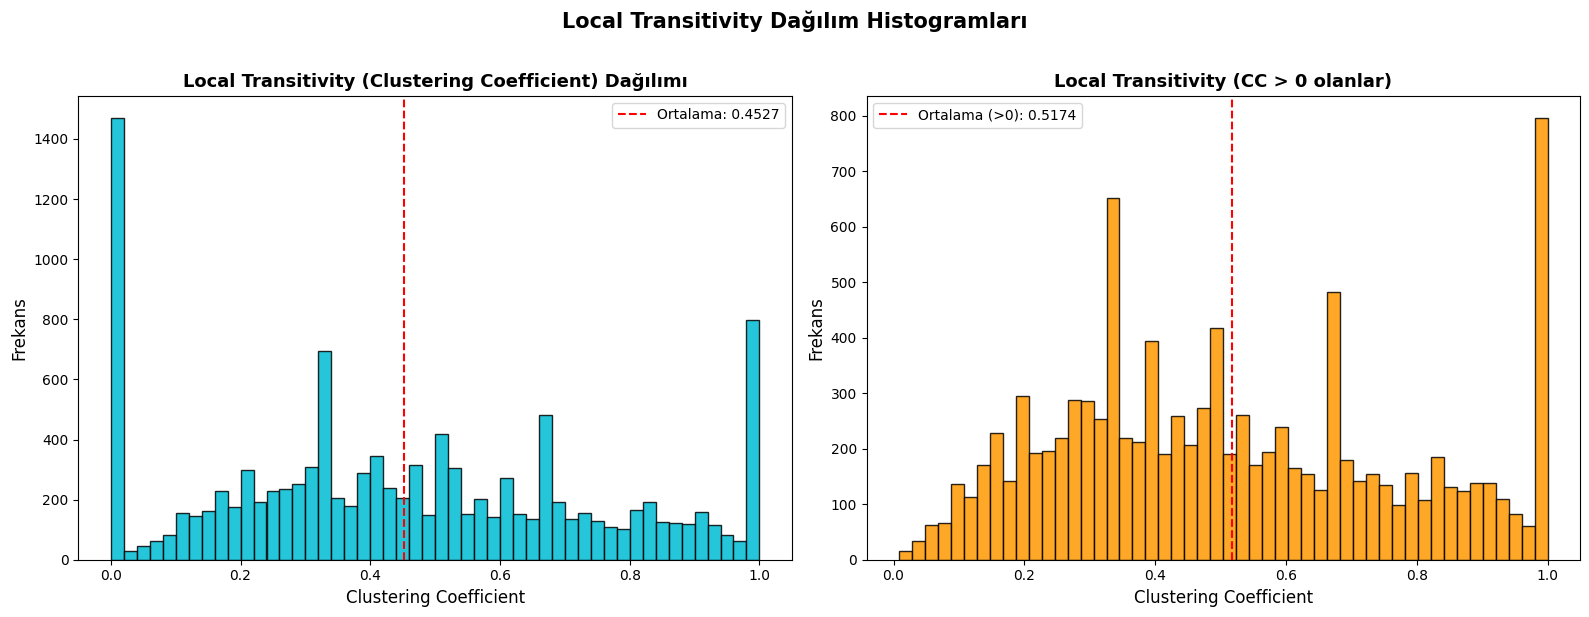


Local Transitivity İstatistikleri:
  Ortalama: 0.4527
  Medyan: 0.4286
  Min: 0.0000, Max: 1.0000
  Std: 0.2991
  Global Transitivity (graf geneli): 0.2623


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tüm node'lar
axes[0].hist(cc_values, bins=50, color='#00BCD4', edgecolor='black', alpha=0.85)
axes[0].set_title('Local Transitivity (Clustering Coefficient) Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clustering Coefficient', fontsize=12)
axes[0].set_ylabel('Frekans', fontsize=12)
axes[0].axvline(np.mean(cc_values), color='red', linestyle='--', label=f'Ortalama: {np.mean(cc_values):.4f}')
axes[0].legend(fontsize=10)

# Sıfır olmayanlar (daha detaylı görmek için)
cc_nonzero = [c for c in cc_values if c > 0]
axes[1].hist(cc_nonzero, bins=50, color='#FF9800', edgecolor='black', alpha=0.85)
axes[1].set_title('Local Transitivity (CC > 0 olanlar)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Clustering Coefficient', fontsize=12)
axes[1].set_ylabel('Frekans', fontsize=12)
axes[1].axvline(np.mean(cc_nonzero), color='red', linestyle='--', label=f'Ortalama (>0): {np.mean(cc_nonzero):.4f}')
axes[1].legend(fontsize=10)

plt.suptitle('Local Transitivity Dağılım Histogramları', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nLocal Transitivity İstatistikleri:")
print(f"  Ortalama: {np.mean(cc_values):.4f}")
print(f"  Medyan: {np.median(cc_values):.4f}")
print(f"  Min: {min(cc_values):.4f}, Max: {max(cc_values):.4f}")
print(f"  Std: {np.std(cc_values):.4f}")
print(f"  Global Transitivity (graf geneli): {nx.transitivity(G_undirected):.4f}")

## 5. Derece ile Benzerlik Metrikleri Karşılaştırması

Her kenar (u→v) için hesaplanan benzerlik/uzaklık metriğini, kaynak (source) ve hedef (target) düğümlerin **derecesi** ile karşılaştırıyoruz.

6 karşılaştırma:
- Cosine Similarity vs Source Degree / Target Degree
- Euclidean Distance vs Source Degree / Target Degree
- Pearson Correlation vs Source Degree / Target Degree

In [18]:
# Her kenar için kaynak/hedef düğüm derecesi ve metrik değerlerini hesapla
import numpy as np
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import pearsonr

src_degrees = []
tgt_degrees = []
edge_cosine = []
edge_pearson = []
edge_euclidean = []

for u, v in G.edges():
    u_s, v_s = str(u), str(v)
    if u_s in emb_dict and v_s in emb_dict:
        eu, ev = emb_dict[u_s], emb_dict[v_s]
        src_degrees.append(G.degree(u))
        tgt_degrees.append(G.degree(v))
        edge_cosine.append(1 - cosine(eu, ev))
        edge_pearson.append(pearsonr(eu, ev)[0])
        edge_euclidean.append(euclidean(eu, ev))

src_degrees = np.array(src_degrees)
tgt_degrees = np.array(tgt_degrees)
edge_cosine = np.array(edge_cosine)
edge_pearson = np.array(edge_pearson)
edge_euclidean = np.array(edge_euclidean)

print(f'Toplam kenar (embedding mevcut): {len(src_degrees)}')

Toplam kenar (embedding mevcut): 291039


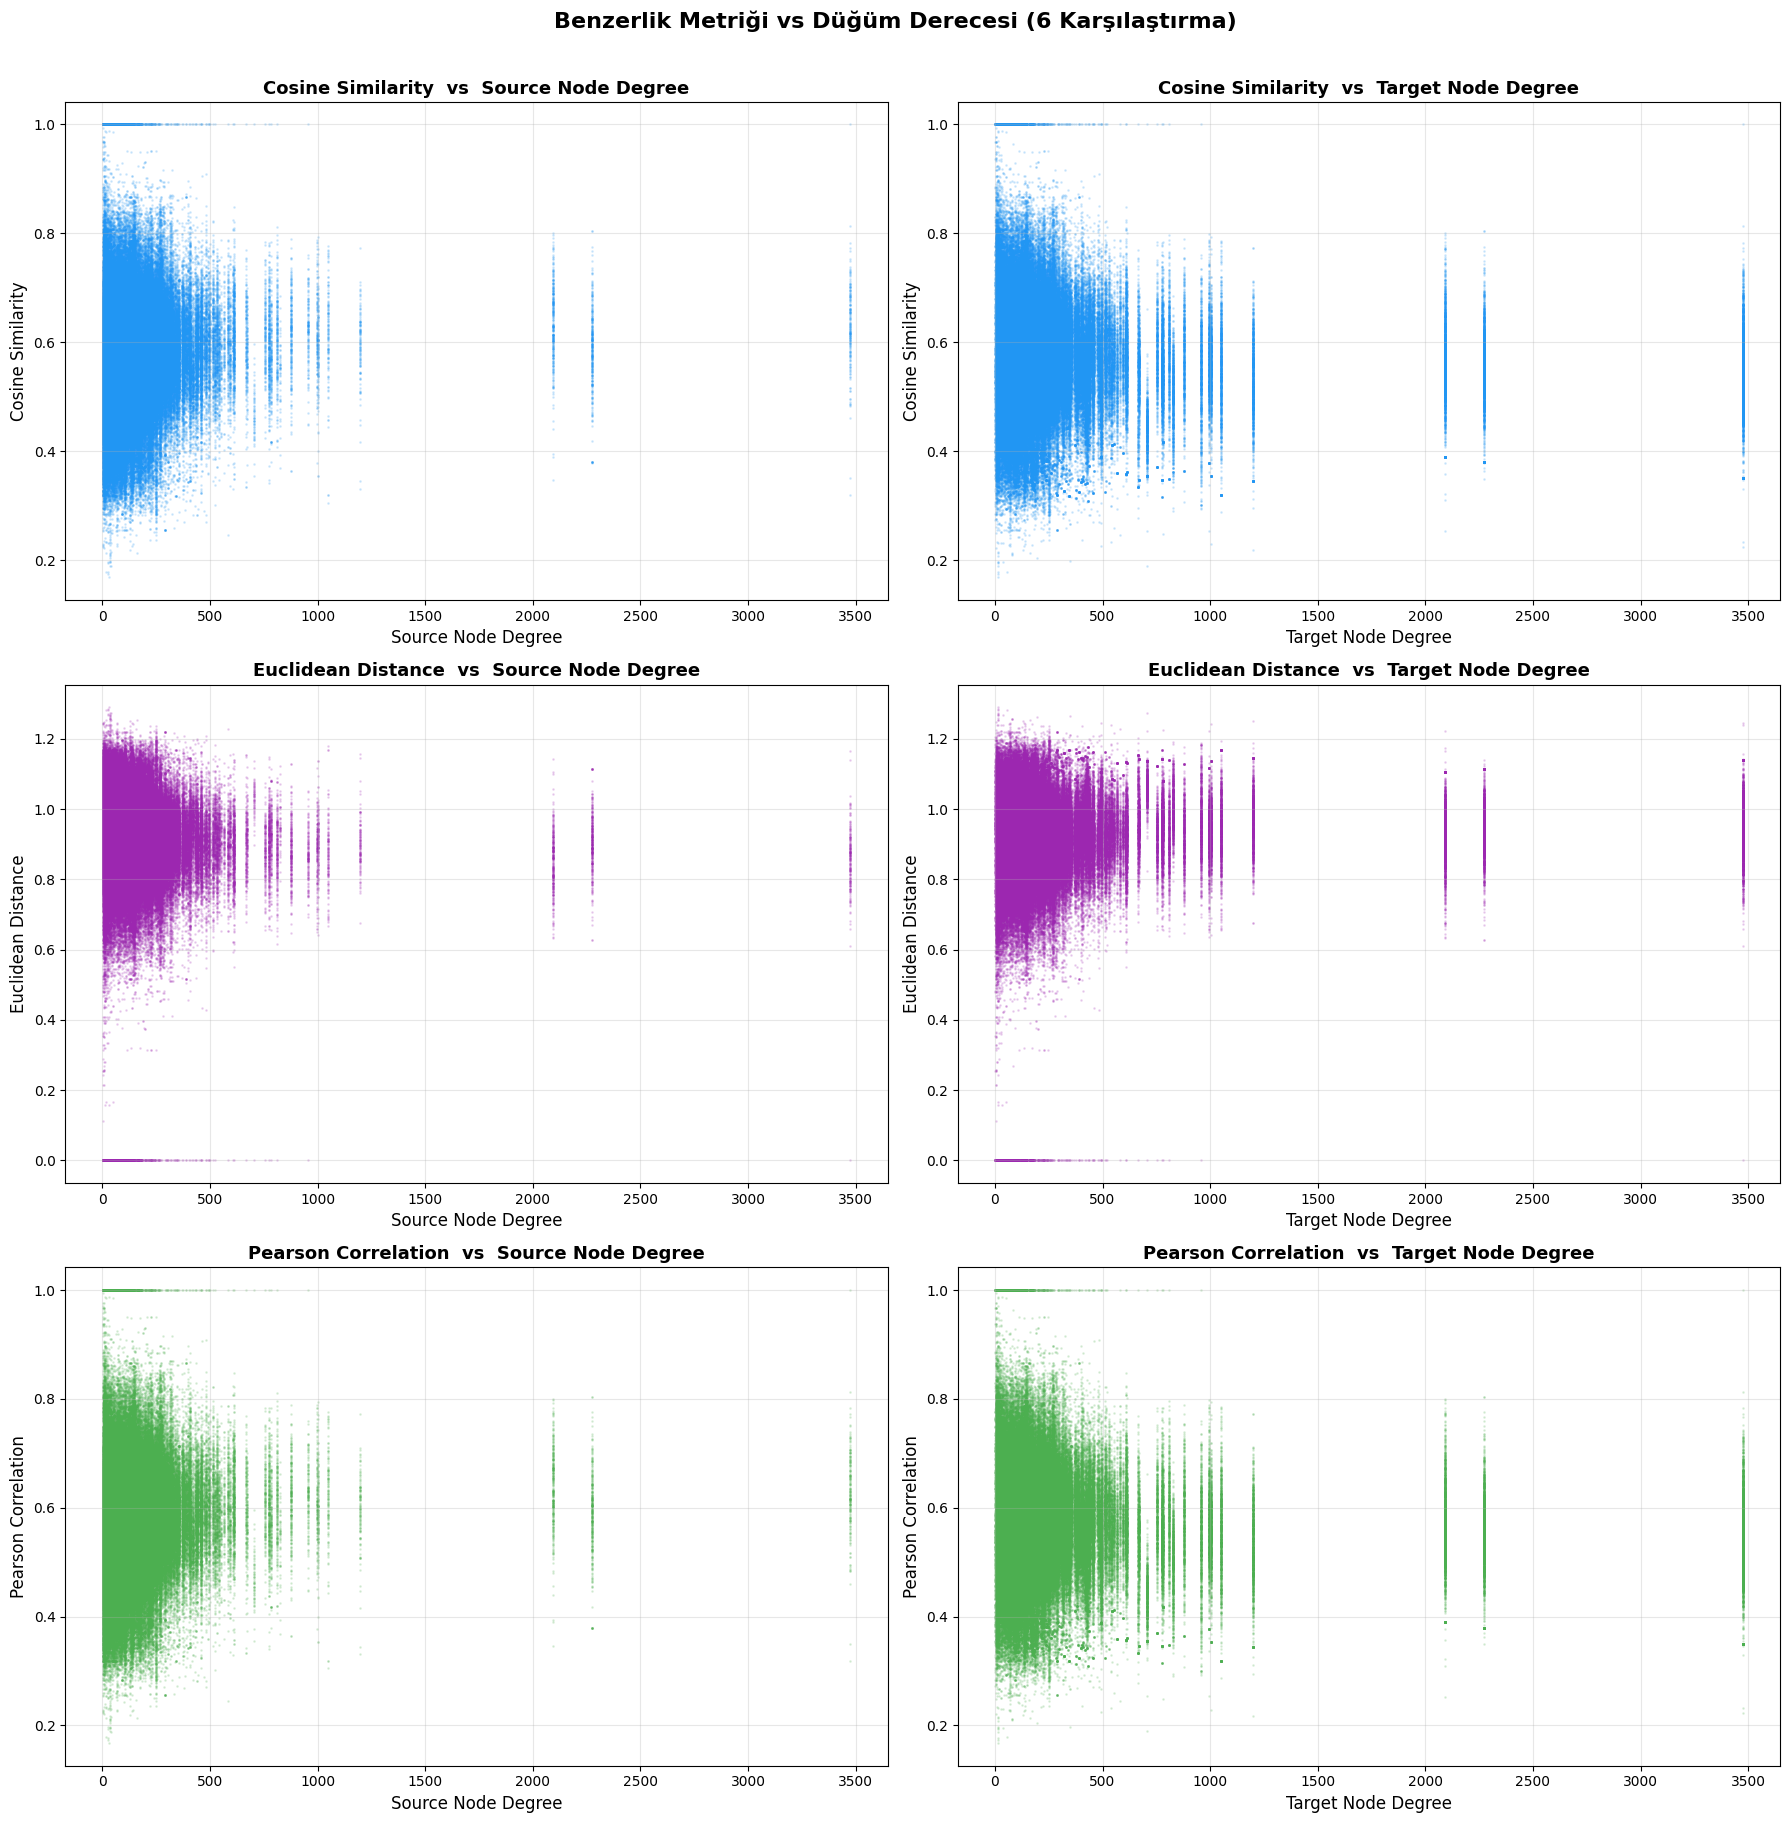

In [19]:
import matplotlib.pyplot as plt

metrics = [
    ('Cosine Similarity', edge_cosine, '#2196F3'),
    ('Euclidean Distance', edge_euclidean, '#9C27B0'),
    ('Pearson Correlation', edge_pearson, '#4CAF50'),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for row, (name, vals, color) in enumerate(metrics):
    for col, (deg_arr, role) in enumerate([(src_degrees, 'Source'), (tgt_degrees, 'Target')]):
        ax = axes[row][col]
        ax.scatter(deg_arr, vals, s=1, alpha=0.15, color=color)
        ax.set_xlabel(f'{role} Node Degree', fontsize=12)
        ax.set_ylabel(name, fontsize=12)
        ax.set_title(f'{name}  vs  {role} Node Degree', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle('Benzerlik Metriği vs Düğüm Derecesi (6 Karşılaştırma)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Local Transitivity (Clustering Coefficient) ile Benzerlik Karşılaştırması

Her kenar (u→v) için **Cosine Similarity** değerini, kaynak ve hedef düğümlerin
**local transitivity (clustering coefficient)** değerleri ile karşılaştırıyoruz.

2 karşılaştırma:
- Cosine Similarity vs Source Node Local Transitivity
- Cosine Similarity vs Target Node Local Transitivity

In [20]:
import networkx as nx

# Undirected versiyonda clustering coefficient hesapla
G_und = G.to_undirected()
cc_dict = nx.clustering(G_und)

src_cc = []
tgt_cc = []
cc_cosine = []

for u, v in G.edges():
    u_s, v_s = str(u), str(v)
    if u_s in emb_dict and v_s in emb_dict:
        eu, ev = emb_dict[u_s], emb_dict[v_s]
        src_cc.append(cc_dict[u])
        tgt_cc.append(cc_dict[v])
        cc_cosine.append(1 - cosine(eu, ev))

src_cc = np.array(src_cc)
tgt_cc = np.array(tgt_cc)
cc_cosine = np.array(cc_cosine)

print(f'Toplam kenar (CC hesaplanmış): {len(src_cc)}')

Toplam kenar (CC hesaplanmış): 291039


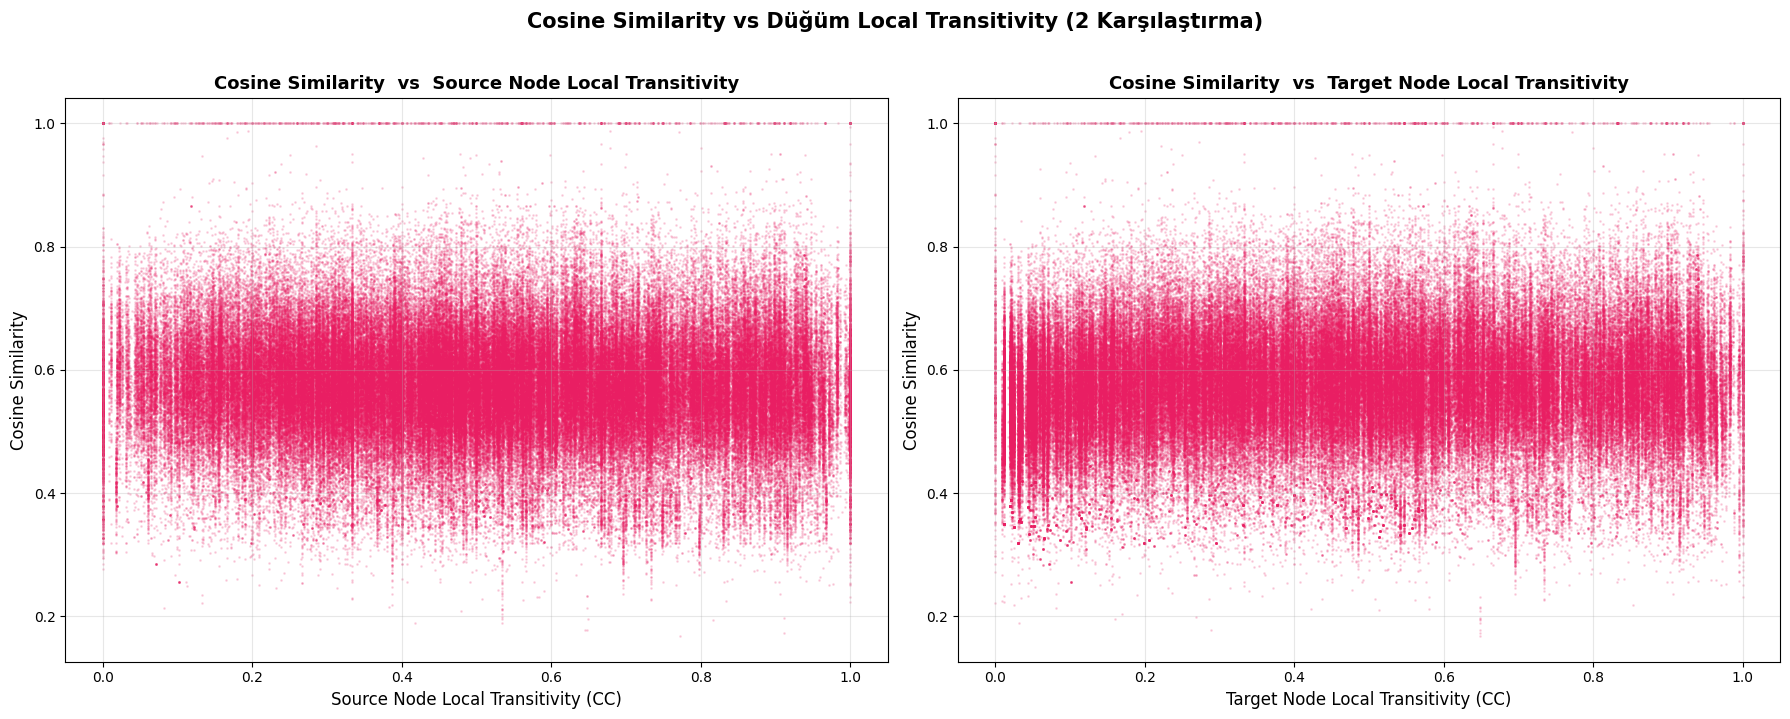

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for col, (cc_arr, role) in enumerate([(src_cc, 'Source'), (tgt_cc, 'Target')]):
    ax = axes[col]
    ax.scatter(cc_arr, cc_cosine, s=1, alpha=0.15, color='#E91E63')
    ax.set_xlabel(f'{role} Node Local Transitivity (CC)', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title(f'Cosine Similarity  vs  {role} Node Local Transitivity',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Cosine Similarity vs Düğüm Local Transitivity (2 Karşılaştırma)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()